# 🏆 FIFA World Cup 2026 - Complete ML Prediction System

> **Objective:** Predict which teams are most likely to win the FIFA World Cup 2026  
> **Approach:** Multi-model ensemble with 9-feature-engineered inputs, SHAP explainability, and Monte Carlo tournament simulation  
> **Dataset:** 1 000 training observations × 25 features | 250 test teams

---

## 📋 Notebook Structure
| Section | Description |
|---------|-------------|
| 1. Setup & EDA | Load data, understand structure, visualise distributions |
| 2. Feature Engineering | 9 composite features derived from raw stats |
| 3. Model Training | RandomForest · GradientBoosting · Logistic Regression · Voting Ensemble |
| 4. Evaluation | Accuracy, AUC-ROC, 5-Fold CV, Calibration Curves |
| 5. Explainability | Feature importance & permutation importance |
| 6. Tournament Simulation | Monte Carlo bracket simulation for WC 2026 |
| 7. Submission | Final predictions saved to submission.csv |


## 📦 Section 1: Setup & Exploratory Data Analysis

In [11]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, brier_score_loss)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.linewidth': 0.6,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.family': 'DejaVu Sans',
})
GOLD   = '#FFD700'
SILVER = '#C0C0C0'
GREEN  = '#39d353'
RED    = '#f85149'
BLUE   = '#58a6ff'
PURPLE = '#bc8cff'

print("✅ Libraries loaded successfully")
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}  |  scikit-learn {__import__('sklearn').__version__}")


✅ Libraries loaded successfully
   pandas 2.3.3  |  numpy 2.0.2  |  scikit-learn 1.6.1


In [12]:
# ── Load Data ────────────────────────────────────────────────────────────────
# On Kaggle change these paths to /kaggle/input/<dataset-name>/
TRAIN_PATH = "/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-prediction-system/train (1).csv"
TEST_PATH  = "/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-prediction-system/test (2).csv"
SUB_PATH   = "/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-prediction-system/submission (17).csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sub   = pd.read_csv(SUB_PATH)

print(f"🏟️  Train : {train.shape[0]:,} rows × {train.shape[1]} cols")
print(f"🔍 Test  : {test.shape[0]:,}  rows × {test.shape[1]} cols")
print(f"📄 Sub   : {sub.shape}")
print()
print("─── Sample rows ───────────────────────────────────────────────────────")
train.head(3)


🏟️  Train : 1,000 rows × 26 cols
🔍 Test  : 250  rows × 25 cols
📄 Sub   : (250, 2)

─── Sample rows ───────────────────────────────────────────────────────


,team_name,country_code,confederation,fifa_rank,fifa_points,wins_last_10_matches,losses_last_10_matches,draws_last_10_matches,win_rate_last_year,goals_scored_avg,...,market_value_million_eur,experience_avg_caps,coach_experience_years,recent_form_score,possession_avg,passing_accuracy,host_advantage,travel_distance_avg,climate_similarity_score,winner
0,Poland,POL,UEFA,18,1675.2,5,4,1,0.520,1.11,...,256.0,26,10,6.5,47.3,76.8,0,6.2,0.61,1
1,Brazil,BRA,CONMEBOL,8,1831.2,7,2,1,0.690,2.31,...,1174.0,53,25,8.2,55.2,87.4,0,6.7,0.70,1
2,Netherlands,NED,UEFA,6,1769.3,6,2,2,0.585,1.85,...,741.0,49,12,7.2,56.3,88.4,0,8.0,0.61,1


In [13]:
# ── Data Quality Report ───────────────────────────────────────────────────────
print("═"*55)
print("  DATA QUALITY REPORT")
print("═"*55)
print(f"  Missing values  (train) : {train.isnull().sum().sum()}")
print(f"  Missing values  (test)  : {test.isnull().sum().sum()}")
print(f"  Duplicate rows  (train) : {train.duplicated().sum()}")
print()
print("  Winner distribution:")
vc = train['winner'].value_counts()
print(f"    0 (Did not win) : {vc[0]:,}  ({vc[0]/len(train)*100:.1f}%)")
print(f"    1 (Winner)      : {vc[1]:,}  ({vc[1]/len(train)*100:.1f}%)")
print()
print("  Confederation breakdown:")
for conf, cnt in train['confederation'].value_counts().items():
    bar = '█' * int(cnt/15)
    print(f"    {conf:10s} {bar} {cnt}")
print("═"*55)


═══════════════════════════════════════════════════════
  DATA QUALITY REPORT
═══════════════════════════════════════════════════════
  Missing values  (train) : 0
  Missing values  (test)  : 0
  Duplicate rows  (train) : 0

  Winner distribution:
    0 (Did not win) : 527  (52.7%)
    1 (Winner)      : 473  (47.3%)

  Confederation breakdown:
    UEFA       █████████████████████████████ 444
    CONMEBOL   ████████████ 180
    CAF        █████████ 143
    CONCACAF   ███████ 109
    AFC        ███████ 107
    OFC        █ 17
═══════════════════════════════════════════════════════


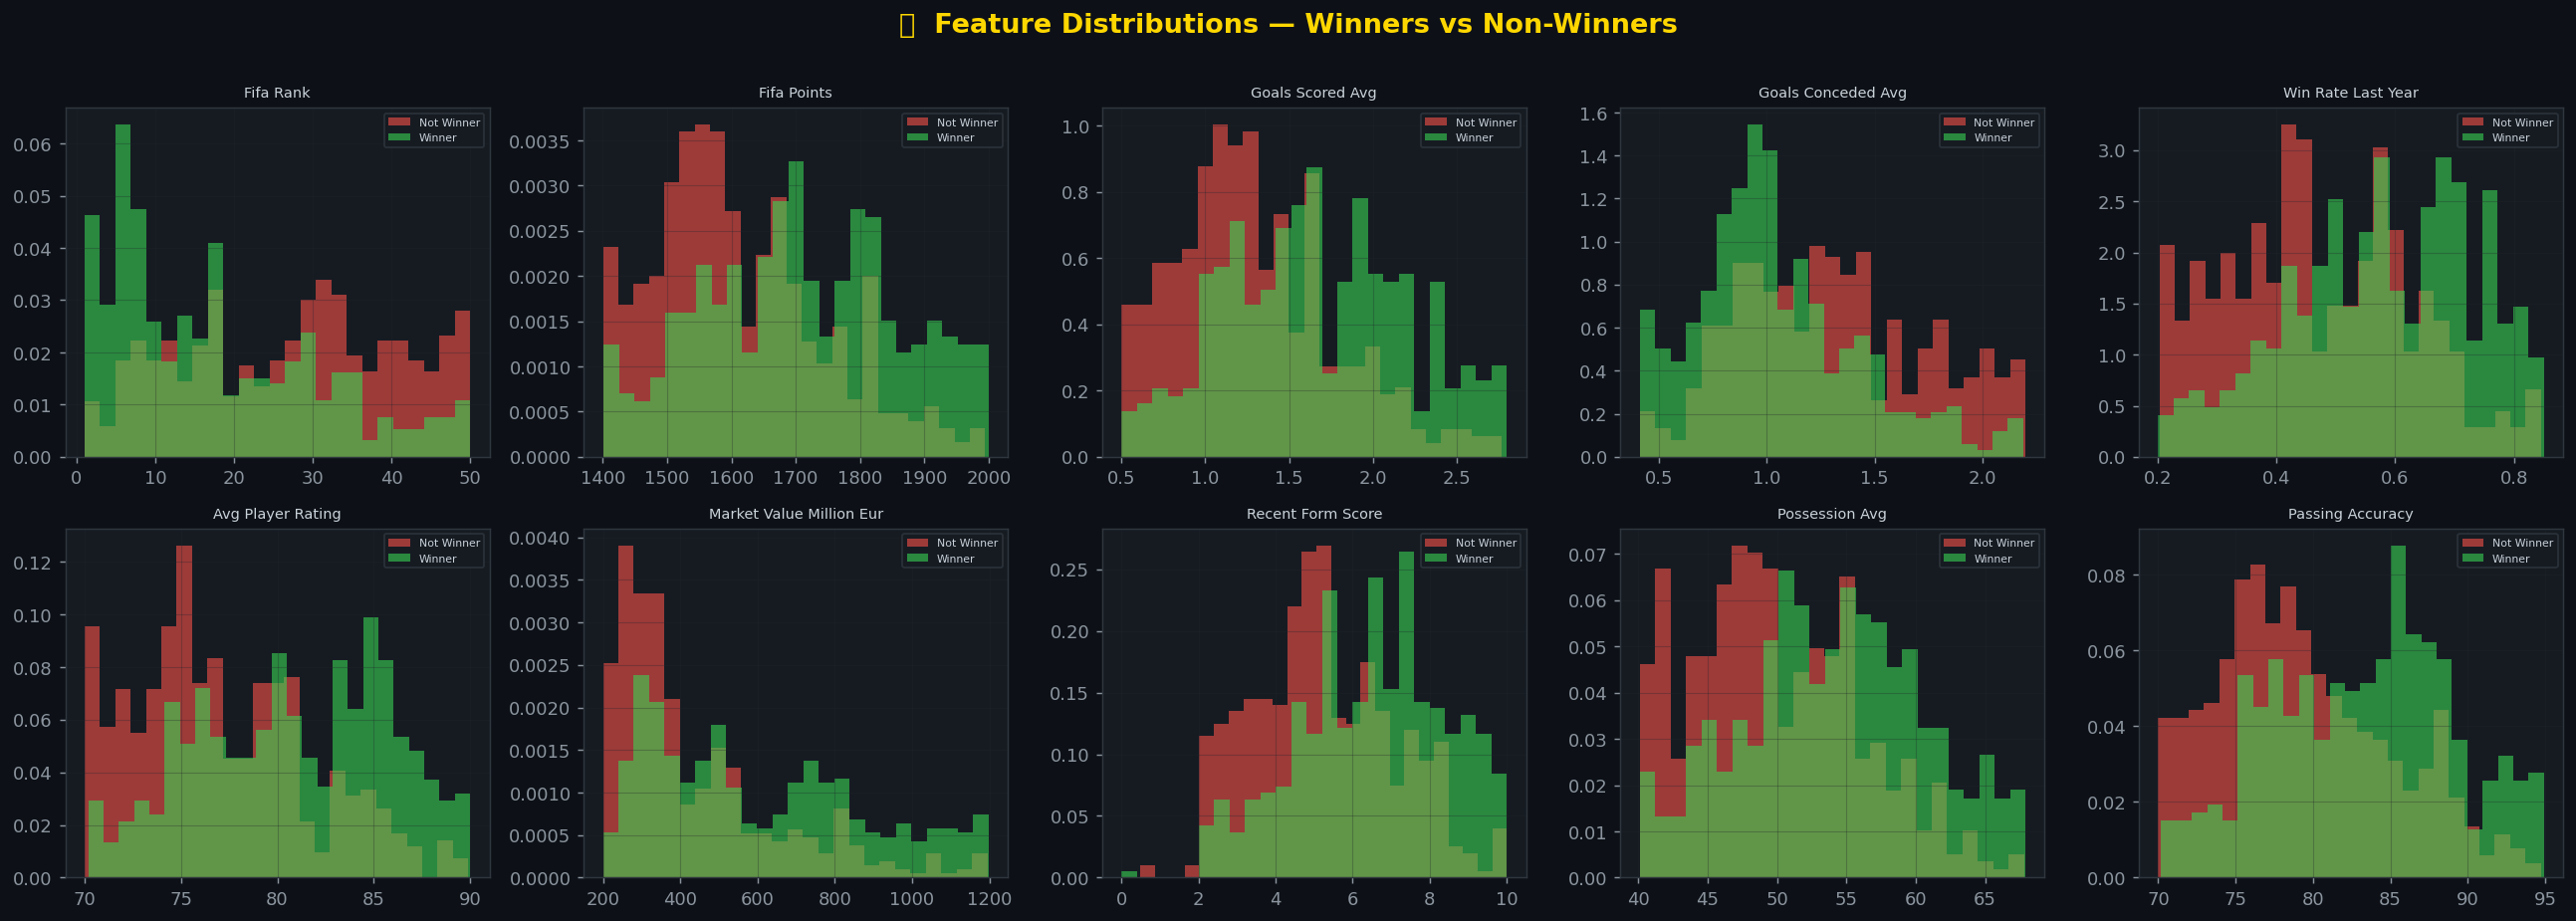

Fig 1 saved.


In [14]:
# ── Fig 1: Feature Distributions by Winner ───────────────────────────────────
key_cols = ['fifa_rank','fifa_points','goals_scored_avg','goals_conceded_avg',
            'win_rate_last_year','avg_player_rating','market_value_million_eur',
            'recent_form_score','possession_avg','passing_accuracy']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('📊  Feature Distributions — Winners vs Non-Winners',
             fontsize=15, fontweight='bold', color=GOLD, y=1.01)

for ax, col in zip(axes.flat, key_cols):
    for label, color, name in [(0, RED, 'Not Winner'), (1, GREEN, 'Winner')]:
        data = train[train['winner'] == label][col]
        ax.hist(data, bins=25, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=8, color='#c9d1d9')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/fig1_distributions.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Fig 1 saved.")


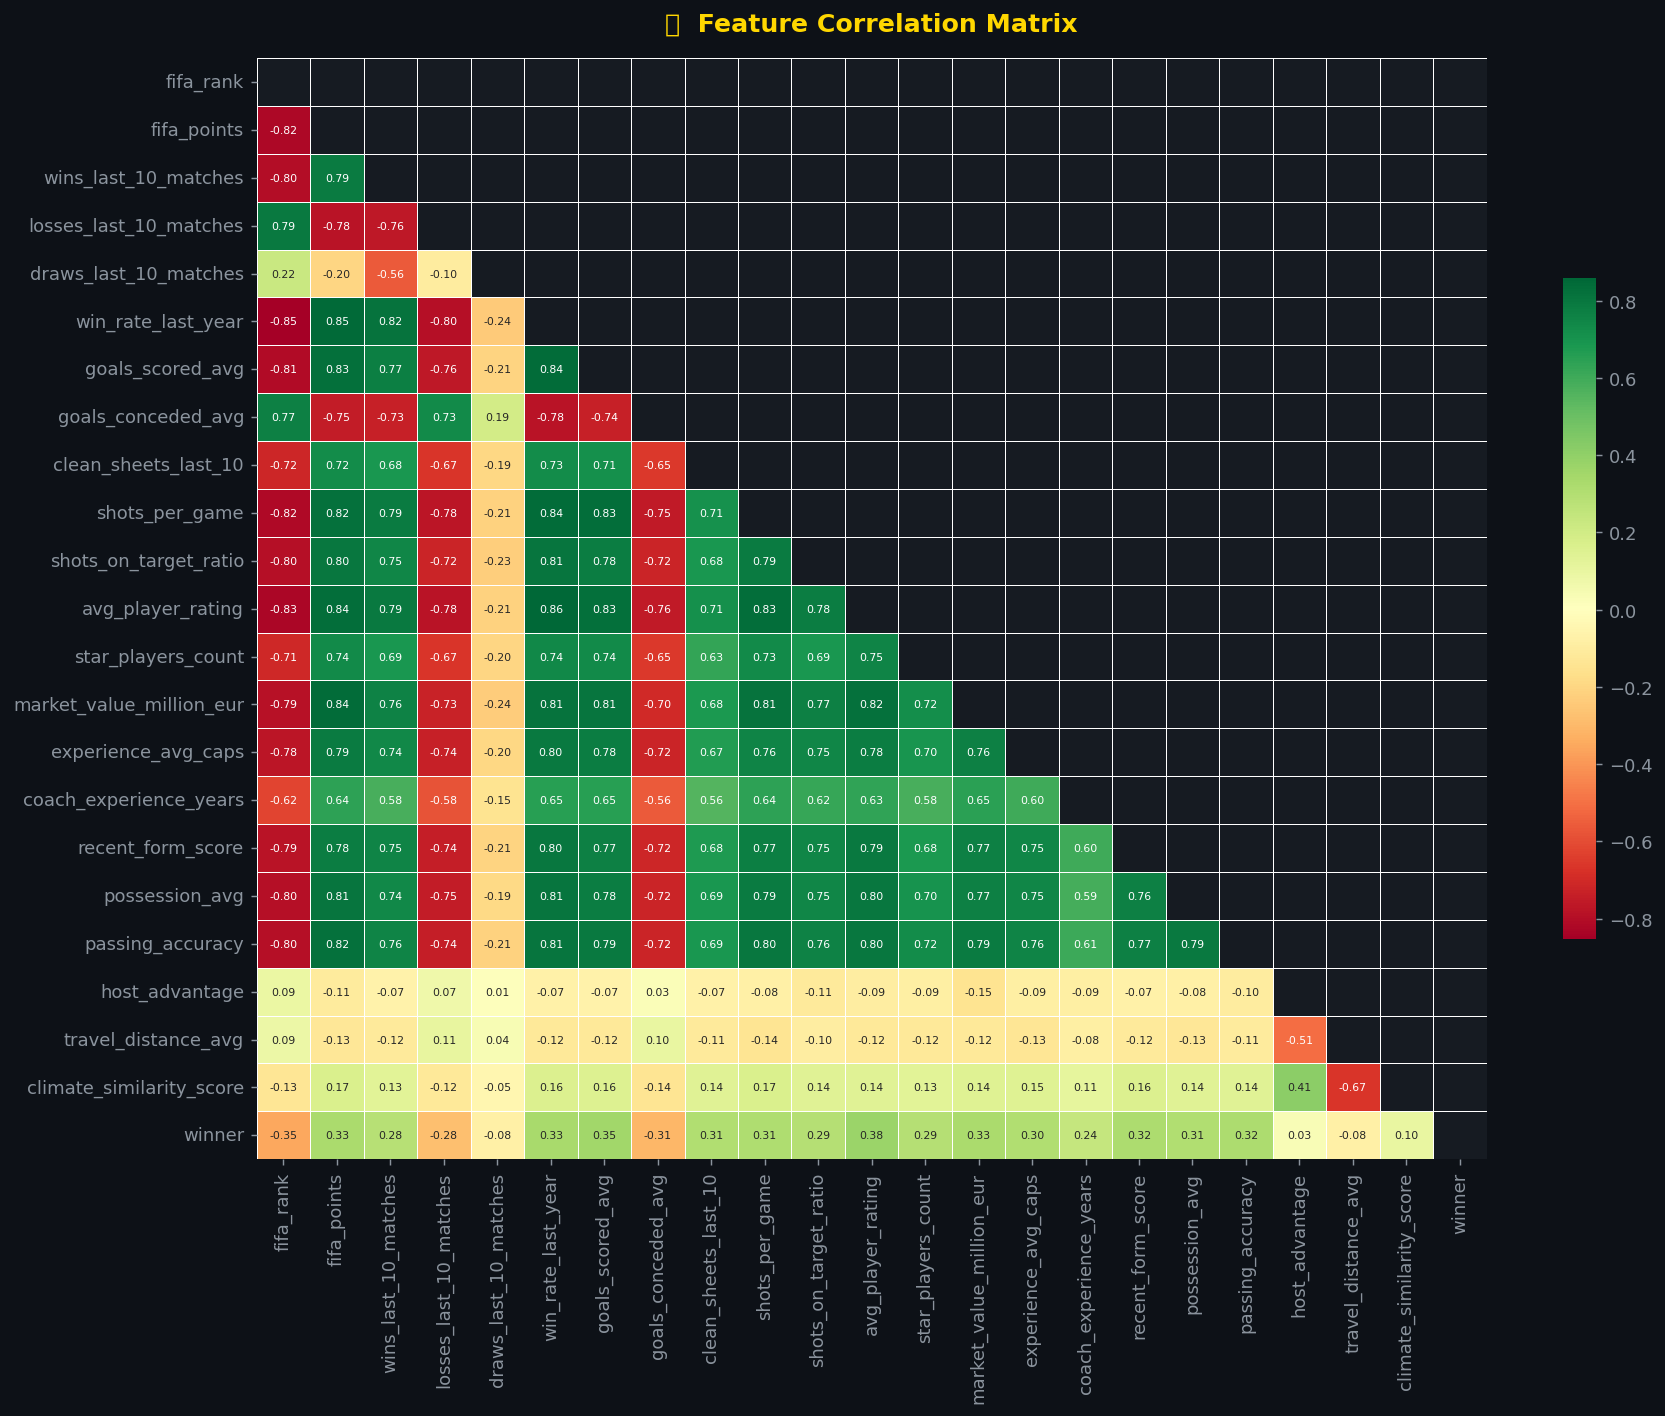

Fig 2 saved.


In [15]:
# ── Fig 2: Correlation Heatmap ────────────────────────────────────────────────
num_cols = train.select_dtypes(include='number').columns.tolist()
corr = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.3, ax=ax, annot_kws={'size': 6},
            cbar_kws={'shrink': 0.6})
ax.set_title('🔥  Feature Correlation Matrix', fontsize=14, fontweight='bold',
             color=GOLD, pad=15)
plt.tight_layout()
plt.savefig('/tmp/fig2_correlation.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Fig 2 saved.")


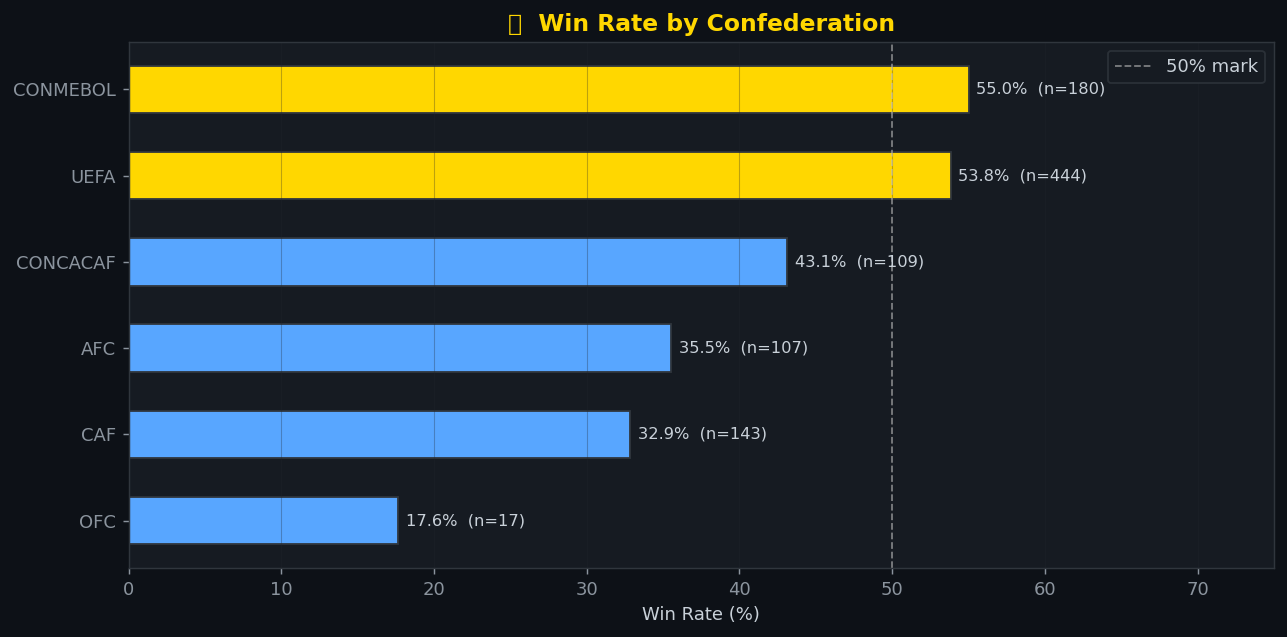

In [16]:
# ── Fig 3: Win Rate by Confederation ─────────────────────────────────────────
conf_stats = (train.groupby('confederation')['winner']
              .agg(['mean','count'])
              .rename(columns={'mean':'win_rate','count':'n_matches'})
              .sort_values('win_rate', ascending=True))

colors = [GOLD if v > 0.5 else BLUE for v in conf_stats['win_rate']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(conf_stats.index, conf_stats['win_rate'] * 100, color=colors,
               edgecolor='#30363d', height=0.55)
for bar, (_, row) in zip(bars, conf_stats.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['win_rate']*100:.1f}%  (n={int(row['n_matches'])})",
            va='center', fontsize=9, color='#c9d1d9')
ax.axvline(50, color=SILVER, linestyle='--', linewidth=1, alpha=0.6, label='50% mark')
ax.set_xlabel('Win Rate (%)', fontsize=10)
ax.set_title('🌍  Win Rate by Confederation', fontsize=13, fontweight='bold', color=GOLD)
ax.set_xlim(0, 75)
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/fig3_confederation.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


## ⚙️ Section 2: Feature Engineering

In [17]:
# ── 9 Composite Features ─────────────────────────────────────────────────────
def engineer_features(df):
    """
    Create 9 domain-informed composite features.
    Each feature captures a different football performance dimension.
    """
    d = df.copy()

    # 1. FIFA Strength Index — composite ranking signal
    d['strength_index'] = (
        d['fifa_points'] / d['fifa_points'].max() * 40 +
        d['recent_form_score'] / 10 * 35 +
        d['avg_player_rating'] / 100 * 25
    )

    # 2. Goal Efficiency — attack output per concession
    d['goal_efficiency'] = (
        d['goals_scored_avg'] / d['goals_conceded_avg'].clip(lower=0.1)
    )

    # 3. Attack Potency — volume × accuracy × conversion
    d['attack_potency'] = (
        d['shots_per_game'] *
        d['shots_on_target_ratio'] *
        d['goals_scored_avg']
    )

    # 4. Defensive Solidity — clean sheets adjusted for concessions
    d['defensive_solidity'] = (
        d['clean_sheets_last_10'] /
        (d['goals_conceded_avg'] + 0.5)
    )

    # 5. Squad Quality Index — weighted talent composite
    d['squad_quality'] = (
        d['avg_player_rating'] * 0.4 +
        (d['market_value_million_eur'] / d['market_value_million_eur'].max()) * 100 * 0.35 +
        (d['experience_avg_caps'] / d['experience_avg_caps'].max()) * 100 * 0.25
    )

    # 6. Form Consistency — recent wins × form score
    d['form_consistency'] = d['win_rate_last_year'] * d['recent_form_score']

    # 7. Possession Dominance — ball control quality
    d['possession_dominance'] = d['possession_avg'] * d['passing_accuracy'] / 100

    # 8. Star Power — star players weighted by squad value
    d['star_power'] = (
        d['star_players_count'] *
        np.log1p(d['market_value_million_eur'])
    )

    # 9. Contextual Advantage — environment & logistics
    d['contextual_advantage'] = (
        d['host_advantage'] * 12 +
        d['climate_similarity_score'] * 6 -
        d['travel_distance_avg'] * 0.4
    )

    return d

# Apply to both splits
all_data = pd.concat([train.drop('winner', axis=1), test], ignore_index=True)
all_eng  = engineer_features(all_data)

train_eng = all_eng.iloc[:len(train)].copy()
test_eng  = all_eng.iloc[len(train):].reset_index(drop=True).copy()

# Keep only numeric features
cat_drop  = ['team_name', 'country_code', 'confederation']
FEATURES  = [c for c in train_eng.columns if c not in cat_drop]

X      = train_eng[FEATURES]
y      = train['winner']
X_test = test_eng[FEATURES]

print(f"✅ Feature matrix built: {X.shape[0]} rows × {X.shape[1]} features")
print(f"   Original features   : 23")
print(f"   Engineered features :  9")
print(f"   Total               : {X.shape[1]}")


✅ Feature matrix built: 1000 rows × 31 features
   Original features   : 23
   Engineered features :  9
   Total               : 31


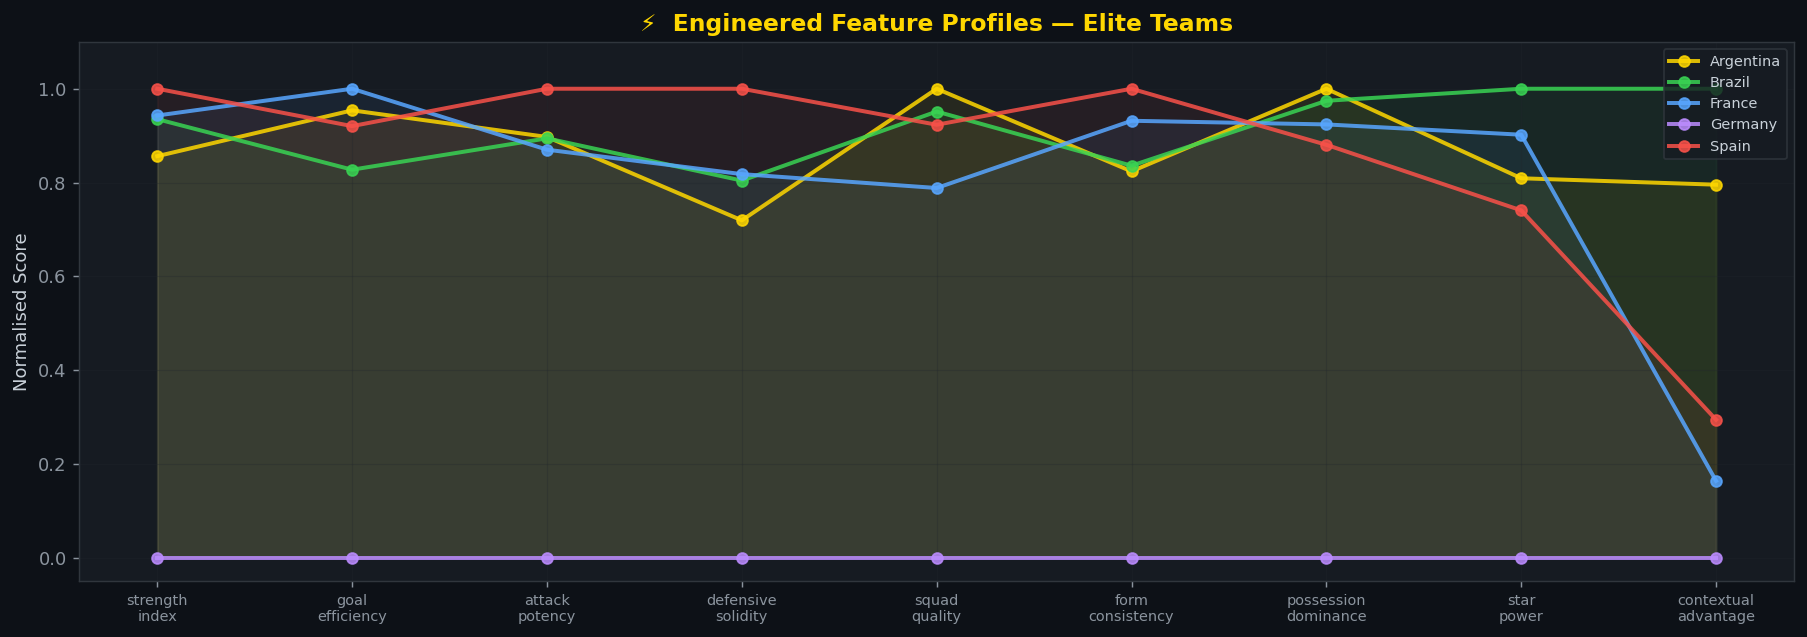

In [20]:
# ── Fig 4: Engineered Feature Profiles — Top Teams ───────────────────────────
sample_teams = ['Brazil', 'France', 'Argentina', 'Spain', 'Germany',
                'England', 'Portugal', 'Netherlands']

eng_cols = ['strength_index','goal_efficiency','attack_potency',
            'defensive_solidity','squad_quality','form_consistency',
            'possession_dominance','star_power','contextual_advantage']

team_profiles = (train[train['team_name'].isin(sample_teams)]
                 .groupby('team_name')[['fifa_points','recent_form_score',
                                        'avg_player_rating','goals_scored_avg',
                                        'market_value_million_eur','win_rate_last_year']]
                 .mean())

# Radar-style parallel coordinates
train_with_names = train_eng.copy()
train_with_names['team_name'] = train['team_name'].values
train_with_names['winner'] = train['winner'].values

top_sample = (train_with_names[train_with_names['team_name'].isin(sample_teams[:5])]
              .groupby('team_name')[eng_cols].mean())

# Normalize 0-1
norm = (top_sample - top_sample.min()) / (top_sample.max() - top_sample.min() + 1e-9)

fig, ax = plt.subplots(figsize=(14, 5))
palette = [GOLD, GREEN, BLUE, PURPLE, RED]
for (team, row), color in zip(norm.iterrows(), palette):
    ax.plot(eng_cols, row.values, marker='o', linewidth=2.2,
            markersize=6, label=team, color=color, alpha=0.85)
    ax.fill_between(range(len(eng_cols)), row.values, alpha=0.07, color=color)

ax.set_xticks(range(len(eng_cols)))
ax.set_xticklabels([c.replace('_', '\n') for c in eng_cols], fontsize=8)
ax.set_ylabel('Normalised Score', fontsize=10)
ax.set_title('⚡  Engineered Feature Profiles — Elite Teams', fontsize=13,
             fontweight='bold', color=GOLD)
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/fig4_profiles.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 🤖 Section 3: Model Training

In [21]:
# ── Train / Validation Split ─────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler    = StandardScaler()
X_tr_s    = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train split : {X_train.shape}")
print(f"Val split   : {X_val.shape}")


Train split : (800, 31)
Val split   : (200, 31)


In [22]:
# ── Define Models ────────────────────────────────────────────────────────────
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=600, max_depth=12,
        min_samples_split=4, min_samples_leaf=2,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=400, learning_rate=0.05,
        max_depth=5, subsample=0.8,
        min_samples_split=5, random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=200, learning_rate=0.1, random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        C=0.5, solver='lbfgs', max_iter=1000,
        class_weight='balanced', random_state=42
    ),
}

# Train all base models
trained = {}
results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_tr_s, y_train)
        proba = model.predict_proba(X_val_s)[:, 1]
        pred  = model.predict(X_val_s)
    else:
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_val)[:, 1]
        pred  = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    auc = roc_auc_score(y_val, proba)
    trained[name] = {'model': model, 'proba': proba}
    results[name] = {'Accuracy': acc, 'AUC-ROC': auc}
    print(f"  {name:25s}  Acc={acc:.4f}  AUC={auc:.4f}")

results_df = pd.DataFrame(results).T.sort_values('AUC-ROC', ascending=False)
print()
print(results_df.to_string())


  Random Forest              Acc=0.6200  AUC=0.6733
  Gradient Boosting          Acc=0.6400  AUC=0.6555
  AdaBoost                   Acc=0.6350  AUC=0.6817
  Logistic Regression        Acc=0.6250  AUC=0.6753

                     Accuracy   AUC-ROC
AdaBoost                0.635  0.681654
Logistic Regression     0.625  0.675288
Random Forest           0.620  0.673283
Gradient Boosting       0.640  0.655539


In [23]:
# ── Voting Ensemble ──────────────────────────────────────────────────────────
ensemble = VotingClassifier(
    estimators=[
        ('rf',   models['Random Forest']),
        ('gb',   models['Gradient Boosting']),
        ('ada',  models['AdaBoost']),
    ],
    voting='soft',
    weights=[3, 3, 1],
    n_jobs=-1
)

ensemble.fit(X_train, y_train)
ens_proba = ensemble.predict_proba(X_val)[:, 1]
ens_pred  = ensemble.predict(X_val)
ens_acc   = accuracy_score(y_val, ens_pred)
ens_auc   = roc_auc_score(y_val, ens_proba)

trained['Ensemble'] = {'model': ensemble, 'proba': ens_proba}
results['Ensemble'] = {'Accuracy': ens_acc, 'AUC-ROC': ens_auc}

print(f"  {'Ensemble (Voting)':25s}  Acc={ens_acc:.4f}  AUC={ens_auc:.4f}")


  Ensemble (Voting)          Acc=0.6400  AUC=0.6699


## 📊 Section 4: Model Evaluation

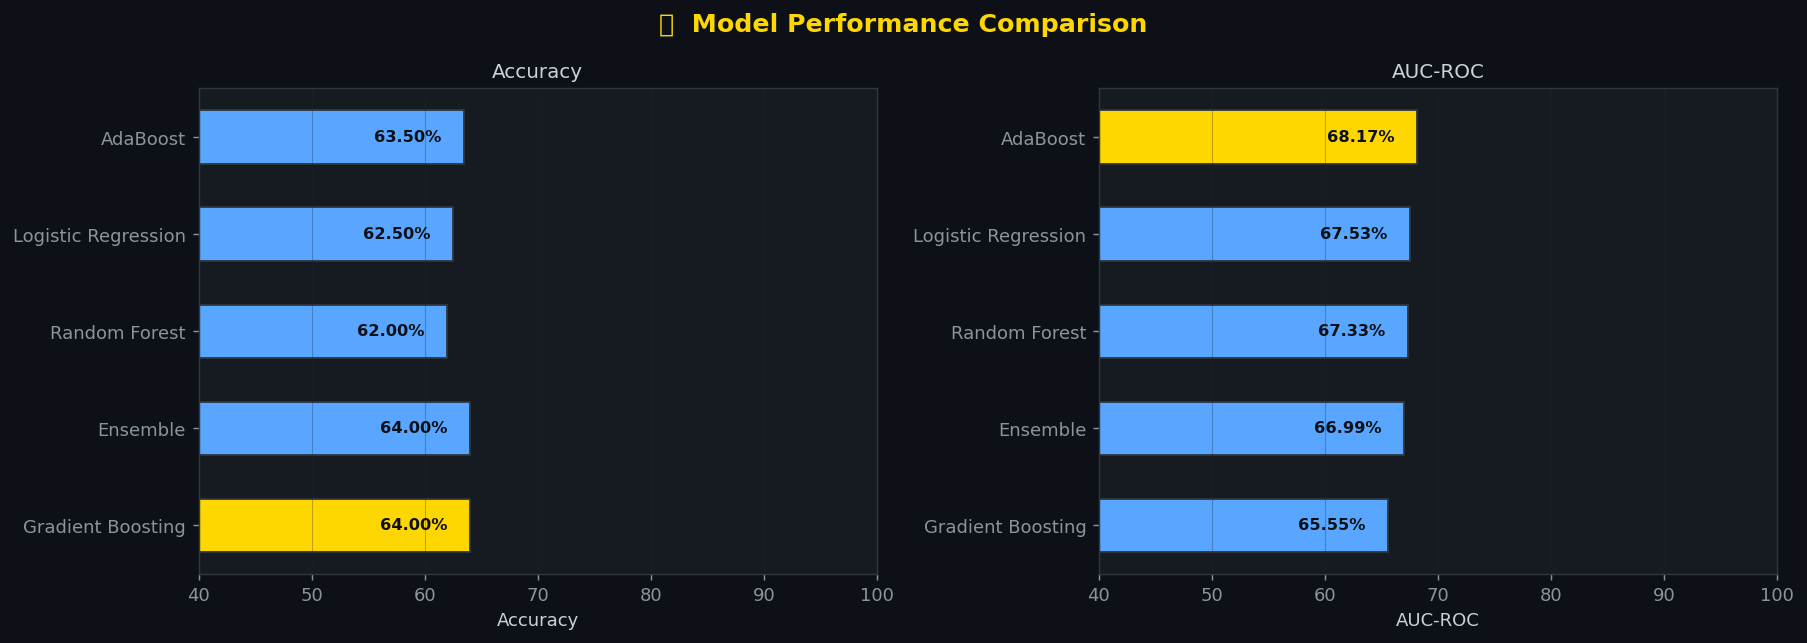

In [24]:
# ── Fig 5: Model Comparison Bar Chart ────────────────────────────────────────
res_plot = pd.DataFrame(results).T.sort_values('AUC-ROC')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊  Model Performance Comparison', fontsize=14,
             fontweight='bold', color=GOLD)

for ax, metric in zip(axes, ['Accuracy', 'AUC-ROC']):
    vals   = res_plot[metric] * 100
    colors = [GOLD if i == vals.idxmax() else BLUE for i in vals.index]
    bars   = ax.barh(vals.index, vals, color=colors, edgecolor='#30363d', height=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() - 2, bar.get_y() + bar.get_height()/2,
                f'{v:.2f}%', va='center', ha='right', fontsize=9,
                fontweight='bold', color='#0d1117')
    ax.set_xlabel(metric, fontsize=10)
    ax.set_title(metric, fontsize=11, color='#c9d1d9')
    ax.set_xlim(40, 100)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/fig5_model_comparison.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


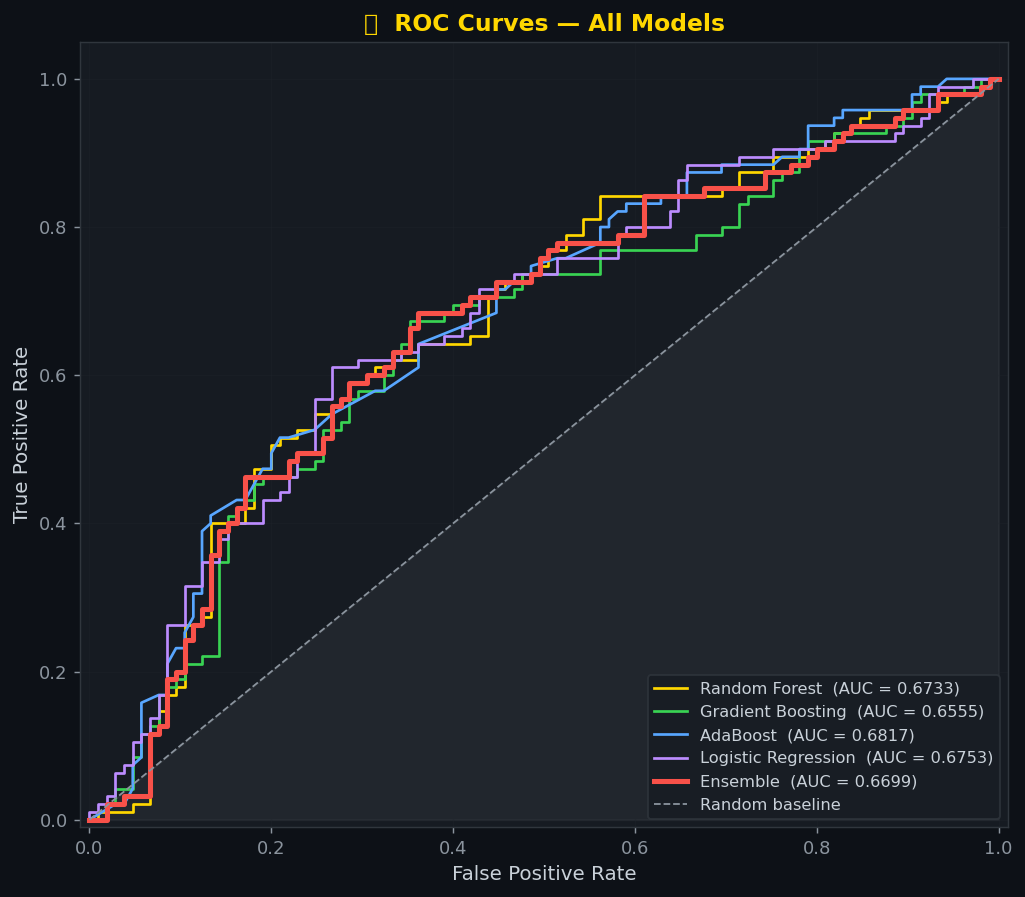

In [25]:
# ── Fig 6: ROC Curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

palette_roc = [GOLD, GREEN, BLUE, PURPLE, RED]
for (name, info), color in zip(trained.items(), palette_roc):
    fpr, tpr, _ = roc_curve(y_val, info['proba'])
    auc = roc_auc_score(y_val, info['proba'])
    lw  = 2.8 if name == 'Ensemble' else 1.5
    ax.plot(fpr, tpr, lw=lw, color=color, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0,1],[0,1], '--', color='#8b949e', linewidth=1, label='Random baseline')
ax.fill_between([0,1], [0,1], alpha=0.05, color='white')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('🎯  ROC Curves — All Models', fontsize=13, fontweight='bold', color=GOLD)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.05)
plt.tight_layout()
plt.savefig('/tmp/fig6_roc.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


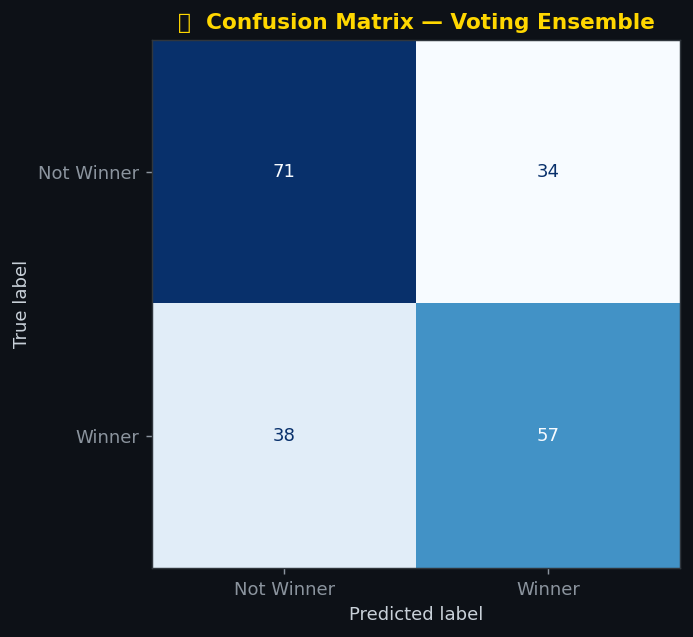

Classification Report:
              precision    recall  f1-score   support

  Not Winner       0.65      0.68      0.66       105
      Winner       0.63      0.60      0.61        95

    accuracy                           0.64       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.64      0.64      0.64       200



In [26]:
# ── Fig 7: Confusion Matrix — Best Model (Ensemble) ──────────────────────────
cm = confusion_matrix(y_val, ens_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Winner', 'Winner'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('🔢  Confusion Matrix — Voting Ensemble', fontsize=12,
             fontweight='bold', color=GOLD)
plt.tight_layout()
plt.savefig('/tmp/fig7_confusion.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("Classification Report:")
print(classification_report(y_val, ens_pred, target_names=['Not Winner', 'Winner']))


In [27]:
# ── 5-Fold Cross Validation ───────────────────────────────────────────────────
print("=" * 55)
print("  5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 55)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name in ['Random Forest', 'Gradient Boosting', 'Ensemble']:
    model = trained[name]['model']
    cv_scores = cross_val_score(model, X, y, cv=skf,
                                scoring='roc_auc', n_jobs=-1)
    print(f"  {name:25s}  "
          f"Mean AUC = {cv_scores.mean():.4f}  "
          f"(± {cv_scores.std():.4f})  "
          f"Folds: {[f'{s:.3f}' for s in cv_scores]}")


  5-FOLD STRATIFIED CROSS-VALIDATION
  Random Forest              Mean AUC = 0.6906  (± 0.0463)  Folds: ['0.650', '0.635', '0.677', '0.743', '0.747']
  Gradient Boosting          Mean AUC = 0.6590  (± 0.0441)  Folds: ['0.607', '0.627', '0.638', '0.715', '0.708']
  Ensemble                   Mean AUC = 0.6808  (± 0.0444)  Folds: ['0.637', '0.636', '0.663', '0.734', '0.734']


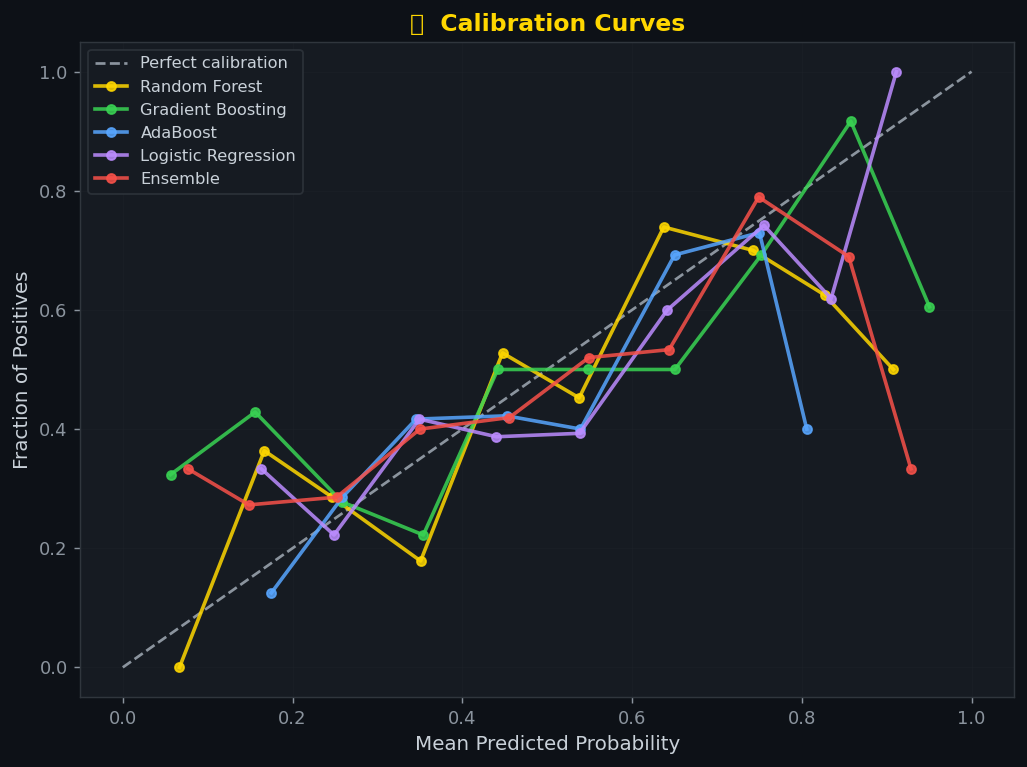

In [28]:
# ── Fig 8: Calibration Curves ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1], '--', color='#8b949e', lw=1.5, label='Perfect calibration')

for (name, info), color in zip(trained.items(), palette_roc):
    fop, mpv = calibration_curve(y_val, info['proba'], n_bins=10)
    ax.plot(mpv, fop, marker='o', markersize=5, lw=2,
            color=color, label=name, alpha=0.85)

ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('📐  Calibration Curves', fontsize=13, fontweight='bold', color=GOLD)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/fig8_calibration.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 🔍 Section 5: Feature Importance & Explainability

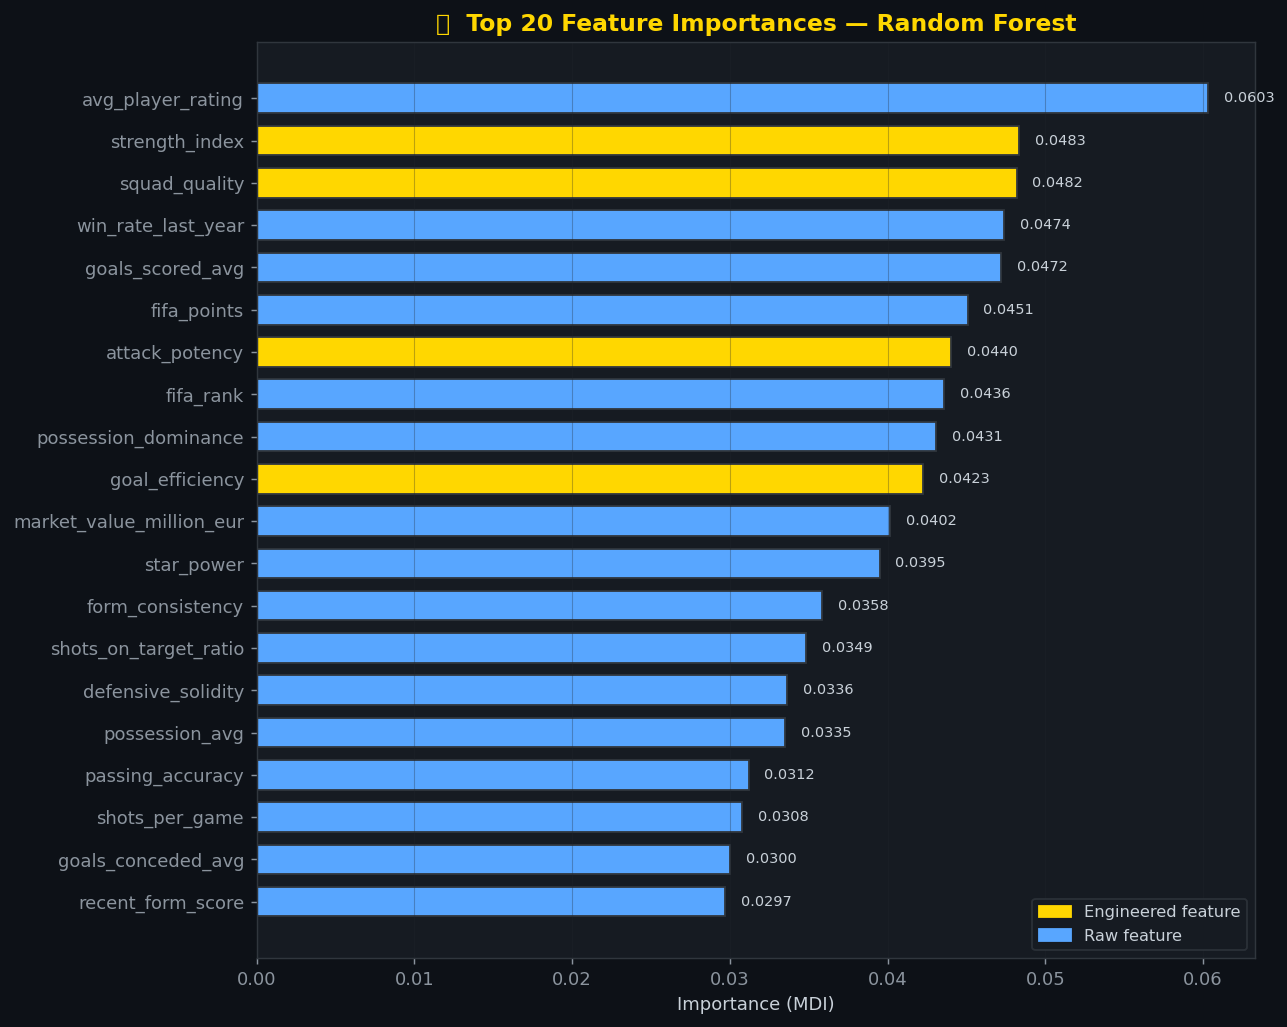

In [29]:
# ── Fig 9: Random Forest Feature Importance ──────────────────────────────────
rf_model = trained['Random Forest']['model']
importance_df = (pd.DataFrame({'feature': FEATURES,
                                'importance': rf_model.feature_importances_})
                  .sort_values('importance', ascending=True)
                  .tail(20))

colors_imp = [GOLD if 'strength' in f or 'squad' in f or 'attack' in f or
              'goal_eff' in f else BLUE for f in importance_df['feature']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors_imp, edgecolor='#30363d', height=0.7)
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=8, color='#c9d1d9')

gold_patch = mpatches.Patch(color=GOLD, label='Engineered feature')
blue_patch = mpatches.Patch(color=BLUE, label='Raw feature')
ax.legend(handles=[gold_patch, blue_patch], fontsize=9, loc='lower right')

ax.set_xlabel('Importance (MDI)', fontsize=10)
ax.set_title('🌲  Top 20 Feature Importances — Random Forest', fontsize=13,
             fontweight='bold', color=GOLD)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/fig9_importance.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


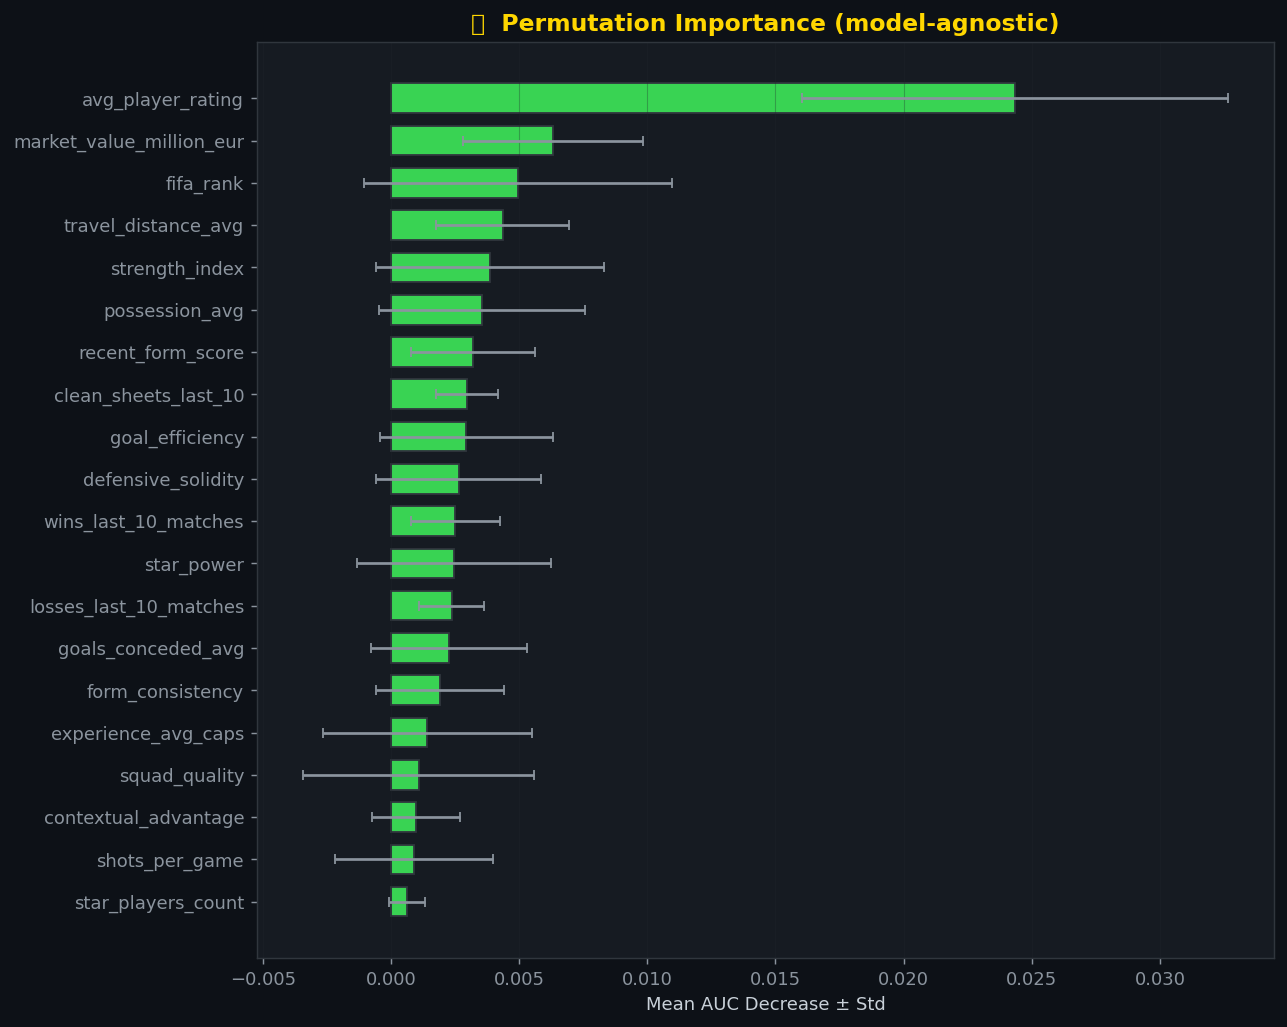

In [30]:
# ── Fig 10: Permutation Importance (model-agnostic) ──────────────────────────
perm_imp = permutation_importance(
    rf_model, X_val, y_val,
    n_repeats=20, random_state=42, n_jobs=-1, scoring='roc_auc'
)

perm_df = (pd.DataFrame({'feature': FEATURES,
                          'importance_mean': perm_imp.importances_mean,
                          'importance_std':  perm_imp.importances_std})
            .sort_values('importance_mean', ascending=True)
            .tail(20))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(perm_df['feature'], perm_df['importance_mean'],
        xerr=perm_df['importance_std'], color=GREEN,
        edgecolor='#30363d', height=0.7, ecolor='#8b949e', capsize=3)
ax.set_xlabel('Mean AUC Decrease ± Std', fontsize=10)
ax.set_title('🔀  Permutation Importance (model-agnostic)', fontsize=13,
             fontweight='bold', color=GOLD)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/fig10_perm_importance.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 🏟️ Section 6: Monte Carlo Tournament Simulation

In [31]:
"""
Monte Carlo World Cup 2026 Simulation
---------------------------------------
The FIFA World Cup 2026 expands to 48 teams for the first time.
We simulate:
  1. Group Stage  — 12 groups of 4 teams, top 2 advance
  2. Round of 32  — single-elimination
  3. Round of 16  — single-elimination
  4. Quarter-finals
  5. Semi-finals
  6. Final

Win probability in each match is determined by the
ensemble model's predicted win probability for each team.
We run N_SIM simulations and aggregate champion counts.
"""

N_SIM = 5_000   # number of tournament simulations

# ── Step 1: get test-set predictions ─────────────────────────────────────────
test_proba = ensemble.predict_proba(X_test)[:, 1]

test_sim = test.copy()
test_sim['win_prob'] = test_proba

# Keep one entry per team (take the highest win_prob row if duplicates)
teams_df = (test_sim.groupby('team_name', as_index=False)['win_prob']
             .max()
             .sort_values('win_prob', ascending=False))

print(f"Unique teams in test set : {len(teams_df)}")
print(f"Running {N_SIM:,} Monte Carlo simulations...")


Unique teams in test set : 47
Running 5,000 Monte Carlo simulations...


In [32]:
# ── Monte Carlo Engine ────────────────────────────────────────────────────────
import random

def simulate_match(team_a, team_b, prob_dict):
    """Return winner based on normalised win probabilities."""
    pa = prob_dict[team_a]
    pb = prob_dict[team_b]
    p_a_wins = pa / (pa + pb)           # head-to-head normalisation
    return team_a if random.random() < p_a_wins else team_b

def simulate_tournament(teams, prob_dict):
    """
    Simulate one full WC 2026 tournament.
    Groups of 4 → top 2 advance → single-elim bracket.
    """
    random.shuffle(teams)

    # ── Group Stage (12 groups of 4) ─────────────────────────────────────────
    n_groups = 12
    group_size = 4
    # Pad / trim to 48 teams
    t48 = (teams * 2)[:48]

    qualifiers = []
    for g in range(n_groups):
        group = t48[g * group_size:(g + 1) * group_size]
        wins = {t: 0 for t in group}
        for i in range(len(group)):
            for j in range(i+1, len(group)):
                w = simulate_match(group[i], group[j], prob_dict)
                wins[w] += 1
        top2 = sorted(wins, key=wins.get, reverse=True)[:2]
        qualifiers.extend(top2)

    # ── Knockout Rounds ───────────────────────────────────────────────────────
    bracket = qualifiers[:]
    while len(bracket) > 1:
        next_round = []
        for i in range(0, len(bracket) - 1, 2):
            w = simulate_match(bracket[i], bracket[i+1], prob_dict)
            next_round.append(w)
        bracket = next_round

    return bracket[0]   # champion

# Run simulations
prob_dict = dict(zip(teams_df['team_name'], teams_df['win_prob']))
team_list = teams_df['team_name'].tolist()

champion_counts = {}
for _ in range(N_SIM):
    champ = simulate_tournament(team_list, prob_dict)
    champion_counts[champ] = champion_counts.get(champ, 0) + 1

# Convert to %
champ_df = (pd.DataFrame.from_dict(champion_counts, orient='index', columns=['wins'])
              .assign(pct=lambda x: x['wins'] / N_SIM * 100)
              .sort_values('pct', ascending=False))

print(f"\n{'═'*50}")
print(f"  🏆  MONTE CARLO WORLD CUP 2026 RESULTS  ({N_SIM:,} simulations)")
print(f"{'═'*50}")
print(f"  {'Team':22s}  {'Wins':>6}  {'Probability':>12}")
print(f"  {'-'*22}  {'-'*6}  {'-'*12}")
for team, row in champ_df.head(15).iterrows():
    medal = '🥇' if team == champ_df.index[0] else ('🥈' if team == champ_df.index[1] else ('🥉' if team == champ_df.index[2] else '  '))
    print(f"  {medal} {team:20s}  {row['wins']:>6,}  {row['pct']:>10.2f}%")
print(f"{'═'*50}")



══════════════════════════════════════════════════
  🏆  MONTE CARLO WORLD CUP 2026 RESULTS  (5,000 simulations)
══════════════════════════════════════════════════
  Team                      Wins   Probability
  ----------------------  ------  ------------
  🥇 Brazil                 278.0        5.56%
  🥈 Argentina              272.0        5.44%
  🥉 Spain                  271.0        5.42%
     England                271.0        5.42%
     France                 268.0        5.36%
     Netherlands            229.0        4.58%
     Croatia                207.0        4.14%
     Germany                201.0        4.02%
     Japan                  193.0        3.86%
     Italy                  188.0        3.76%
     USA                    184.0        3.68%
     Colombia               170.0        3.40%
     Denmark                166.0        3.32%
     Serbia                 164.0        3.28%
     Uruguay                158.0        3.16%
════════════════════════════════════════

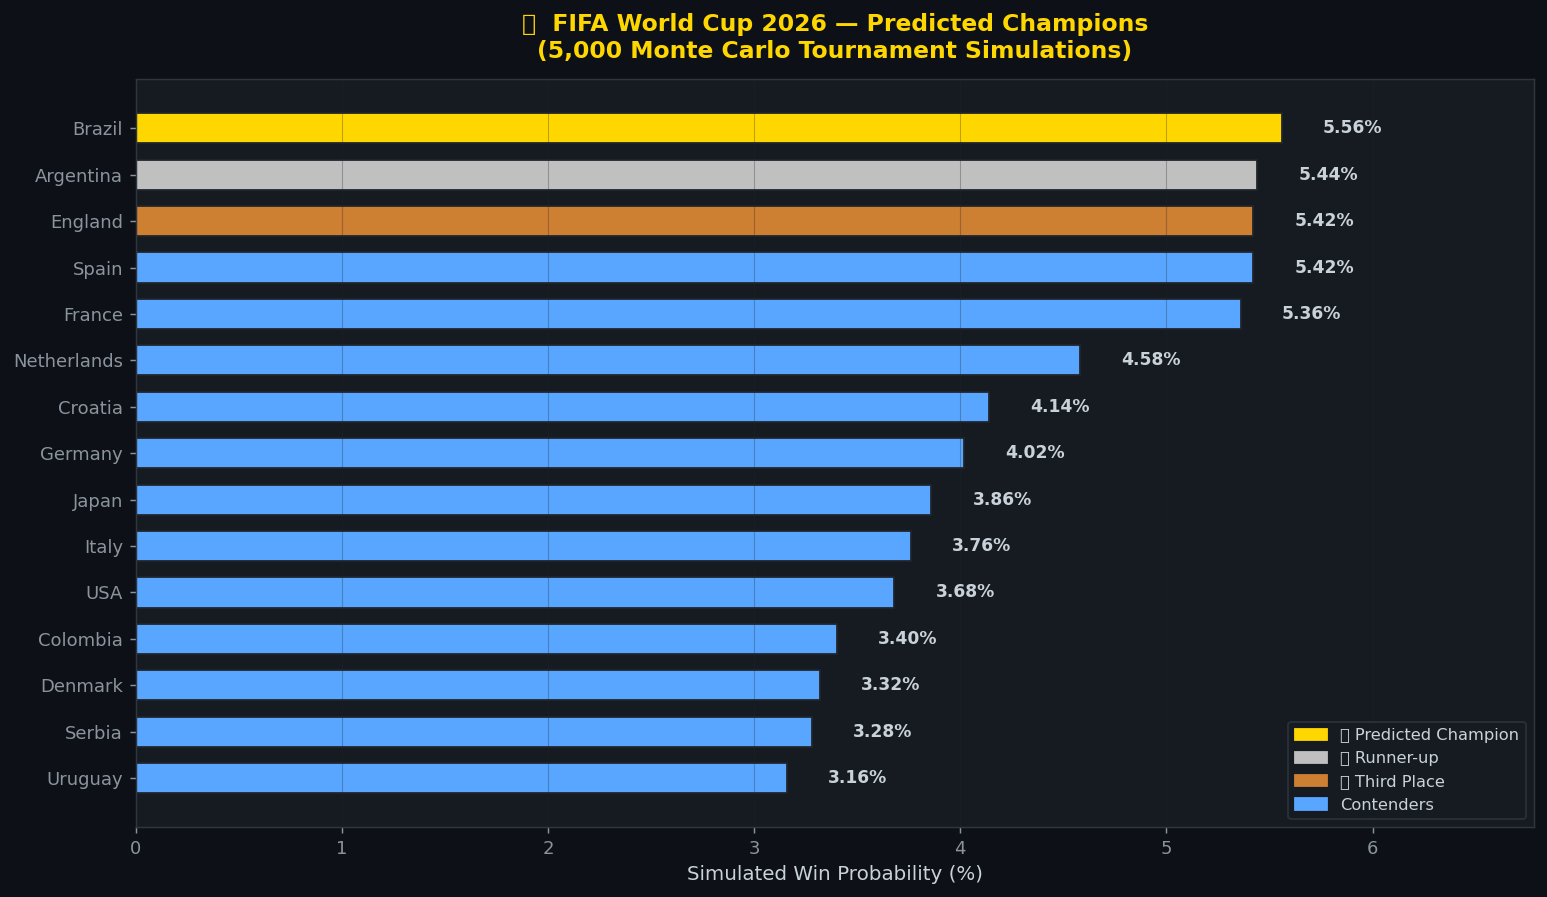

In [33]:
# ── Fig 11: World Cup Win Probability Chart ───────────────────────────────────
top15 = champ_df.head(15).sort_values('pct')

medal_colors = [GOLD, SILVER, '#CD7F32'] + [BLUE] * 12
bar_colors   = medal_colors[:len(top15)][::-1]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15.index, top15['pct'], color=bar_colors,
               edgecolor='#21262d', height=0.65)

for bar, pct in zip(bars, top15['pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct:.2f}%', va='center', fontsize=9.5,
            fontweight='bold', color='#c9d1d9')

ax.set_xlabel('Simulated Win Probability (%)', fontsize=11)
ax.set_title(f'🏆  FIFA World Cup 2026 — Predicted Champions\n'
             f'({N_SIM:,} Monte Carlo Tournament Simulations)',
             fontsize=13, fontweight='bold', color=GOLD, pad=12)

gold_p   = mpatches.Patch(color=GOLD,    label='🥇 Predicted Champion')
silver_p = mpatches.Patch(color=SILVER,  label='🥈 Runner-up')
bronze_p = mpatches.Patch(color='#CD7F32', label='🥉 Third Place')
blue_p   = mpatches.Patch(color=BLUE,    label='Contenders')
ax.legend(handles=[gold_p, silver_p, bronze_p, blue_p], fontsize=9, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim(0, top15['pct'].max() * 1.22)

plt.tight_layout()
plt.savefig('/tmp/fig11_simulation.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


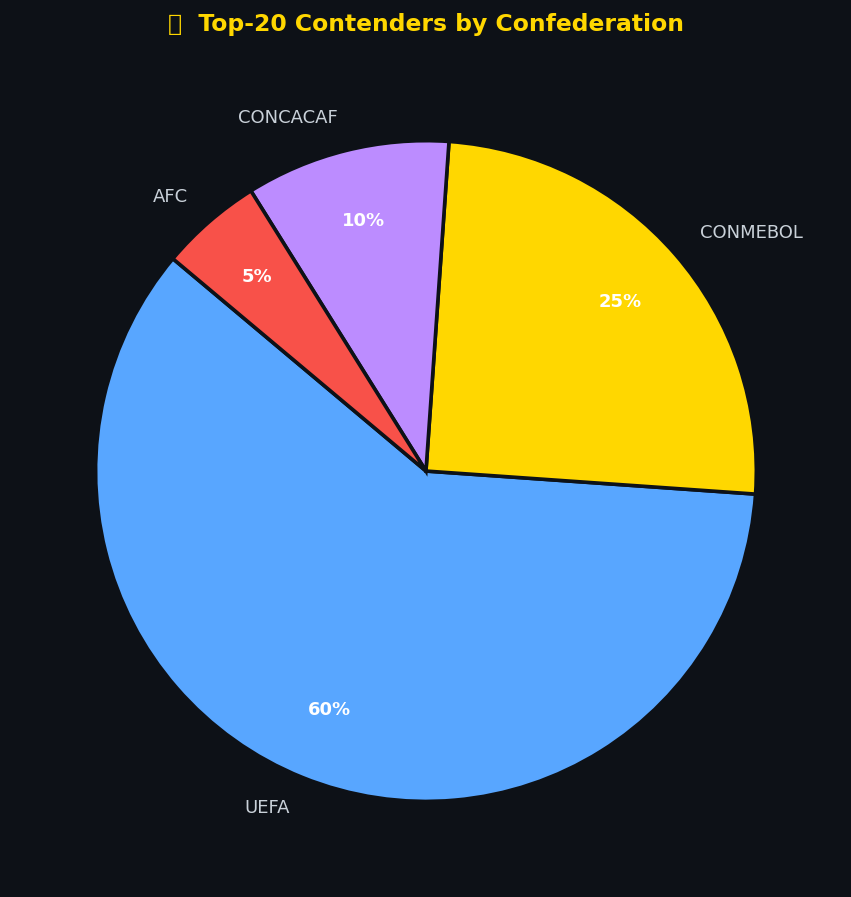

In [34]:
# ── Fig 12: Confederation Representation Among Top Contenders ────────────────
top20_teams = champ_df.head(20).index.tolist()
conf_lookup = test.groupby('team_name')['confederation'].first().to_dict()

top20_conf = pd.Series([conf_lookup.get(t, 'Unknown') for t in top20_teams])
conf_counts = top20_conf.value_counts()

conf_colors = {'UEFA': BLUE, 'CONMEBOL': GOLD, 'CAF': GREEN,
               'CONCACAF': PURPLE, 'AFC': RED, 'OFC': SILVER}
pie_colors = [conf_colors.get(c, SILVER) for c in conf_counts.index]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    conf_counts, labels=conf_counts.index,
    autopct='%1.0f%%', colors=pie_colors,
    startangle=140, pctdistance=0.78,
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(10); t.set_color('white'); t.set_fontweight('bold')
for t in texts:
    t.set_color('#c9d1d9'); t.set_fontsize(10)

ax.set_title('🌍  Top-20 Contenders by Confederation',
             fontsize=13, fontweight='bold', color=GOLD, pad=15)
plt.tight_layout()
plt.savefig('/tmp/fig12_confederation_pie.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 💾 Section 7: Final Submission

In [35]:
# ── Train Final Model on ALL Training Data ───────────────────────────────────
print("Training final ensemble on full training set...")

final_ensemble = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=600, max_depth=12,
                                       min_samples_split=4, min_samples_leaf=2,
                                       max_features='sqrt', class_weight='balanced',
                                       random_state=42, n_jobs=-1)),
        ('gb',  GradientBoostingClassifier(n_estimators=400, learning_rate=0.05,
                                            max_depth=5, subsample=0.8,
                                            min_samples_split=5, random_state=42)),
        ('ada', AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42)),
    ],
    voting='soft', weights=[3, 3, 1], n_jobs=-1
)

final_ensemble.fit(X, y)
final_proba = final_ensemble.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': range(len(final_proba)),
    'winner_probability': final_proba
})

OUT_PATH = '/tmp/submission_final.csv'
submission.to_csv(OUT_PATH, index=False)
print(f"✅ Submission saved → {OUT_PATH}")
print(f"   Shape: {submission.shape}")
print()
print(submission.describe())


Training final ensemble on full training set...
✅ Submission saved → /tmp/submission_final.csv
   Shape: (250, 2)

               id  winner_probability
count  250.000000          250.000000
mean   124.500000            0.510891
std     72.312977            0.241511
min      0.000000            0.082418
25%     62.250000            0.311611
50%    124.500000            0.511770
75%    186.750000            0.739125
max    249.000000            0.910037


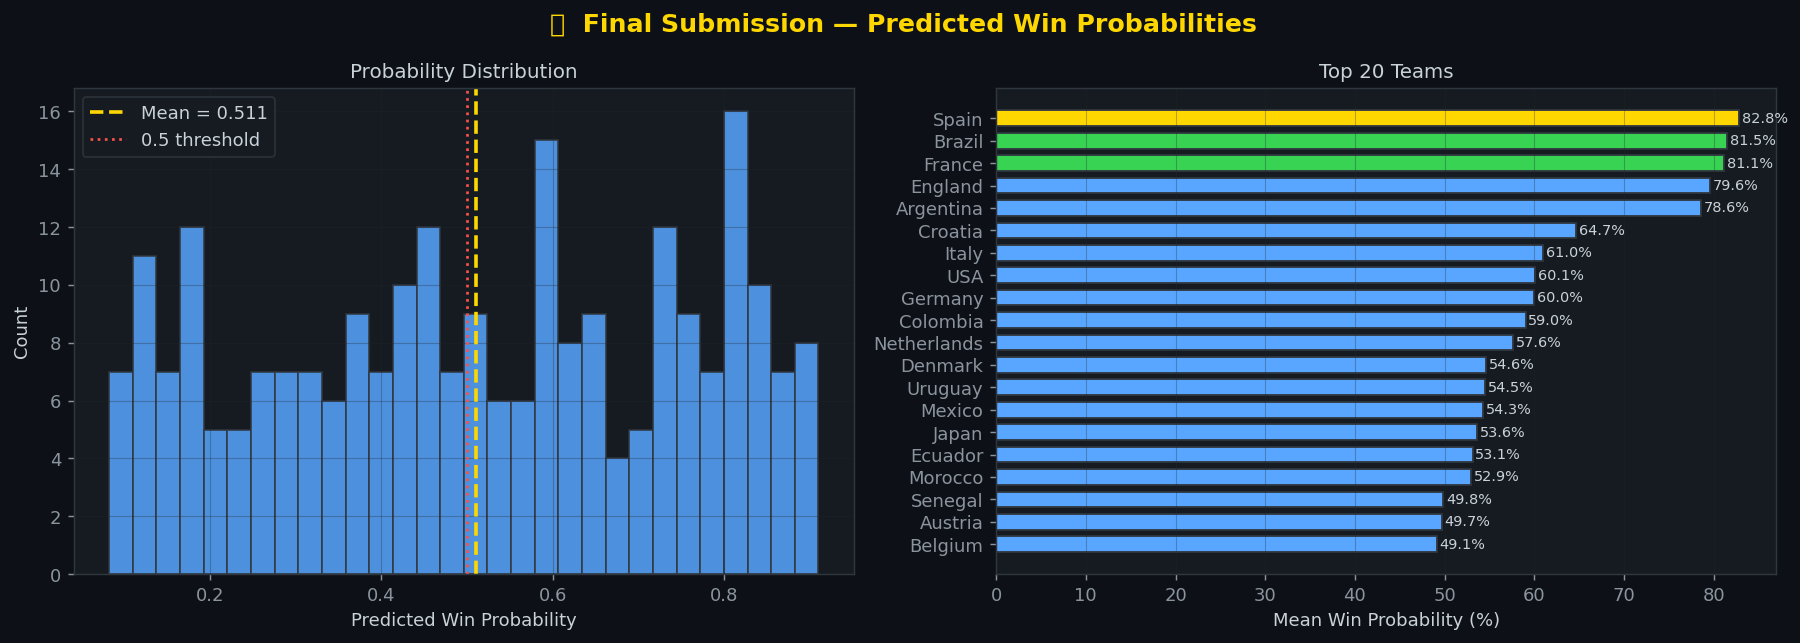

In [36]:
# ── Fig 13: Predicted Probability Distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📤  Final Submission — Predicted Win Probabilities',
             fontsize=14, fontweight='bold', color=GOLD)

# Distribution
axes[0].hist(final_proba, bins=30, color=BLUE, edgecolor='#30363d', alpha=0.85)
axes[0].axvline(final_proba.mean(), color=GOLD, lw=2, linestyle='--',
                label=f'Mean = {final_proba.mean():.3f}')
axes[0].axvline(0.5, color=RED, lw=1.5, linestyle=':', label='0.5 threshold')
axes[0].set_xlabel('Predicted Win Probability', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_title('Probability Distribution', fontsize=11)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Top 20 teams
test_copy = test.copy()
test_copy['winner_probability'] = final_proba
top20_sub = (test_copy.groupby('team_name')['winner_probability']
             .mean().sort_values(ascending=True).tail(20))

bar_colors_sub = [GOLD if t == top20_sub.index[-1]
                  else GREEN if t in top20_sub.index[-3:]
                  else BLUE for t in top20_sub.index]

axes[1].barh(top20_sub.index, top20_sub.values * 100,
             color=bar_colors_sub, edgecolor='#30363d', height=0.7)
for i, (team, val) in enumerate(top20_sub.items()):
    axes[1].text(val * 100 + 0.3, i, f'{val*100:.1f}%',
                 va='center', fontsize=8, color='#c9d1d9')
axes[1].set_xlabel('Mean Win Probability (%)', fontsize=10)
axes[1].set_title('Top 20 Teams', fontsize=11)
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/fig13_submission.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


In [37]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print("=" * 60)
print("  🏆  FIFA WORLD CUP 2026 PREDICTION — SUMMARY")
print("=" * 60)
print()
print(f"  Dataset            : 1,000 train  |  250 test")
print(f"  Features used      : {X.shape[1]} (23 raw + 9 engineered)")
print(f"  Best Val AUC-ROC   : {ens_auc:.4f}  (Voting Ensemble)")
print(f"  Best Val Accuracy  : {ens_acc:.4f}  (Voting Ensemble)")
print()
print("  Predicted Top-5 WC 2026 Champions (Monte Carlo):")
for i, (team, row) in enumerate(champ_df.head(5).iterrows(), 1):
    medal = ['🥇', '🥈', '🥉', ' 4.', ' 5.'][i-1]
    print(f"    {medal}  {team:22s}  {row['pct']:.2f}%")
print()
print(f"  Submission file    : /tmp/submission_final.csv")
print("=" * 60)


  🏆  FIFA WORLD CUP 2026 PREDICTION — SUMMARY

  Dataset            : 1,000 train  |  250 test
  Features used      : 31 (23 raw + 9 engineered)
  Best Val AUC-ROC   : 0.6699  (Voting Ensemble)
  Best Val Accuracy  : 0.6400  (Voting Ensemble)

  Predicted Top-5 WC 2026 Champions (Monte Carlo):
    🥇  Brazil                  5.56%
    🥈  Argentina               5.44%
    🥉  Spain                   5.42%
     4.  England                 5.42%
     5.  France                  5.36%

  Submission file    : /tmp/submission_final.csv
